In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

## Load Data From CSV File

In [14]:
df = pd.read_csv("Heart.csv")
print(df.head(5))
print("\n", df['output'].value_counts())

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  

 output
1    165
0    138
Name: count, dtype: int64


In [15]:
df.head()
print(df.shape)

(303, 14)


# Preprocessing

In [16]:

# Load data
df = pd.read_csv("Heart.csv")

# Replace missing-value markers
df = df.replace("?", np.nan)

# Convert columns to numeric
cols = [
    'age', 'sex', 'cp', 'trtbps', 'chol', 'fbs',
    'restecg', 'thalachh', 'exng', 'oldpeak',
    'slp', 'caa', 'thall', 'output'
]

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=cols)

# Remove duplicated rows
# df = df.drop_duplicates()

# Fill missing values
numeric_cols = [
    'age', 'trtbps', 'chol',
    'thalachh', 'oldpeak', 'caa', 'thall'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Remove clearly invalid values
df = df[df['age'] > 0]
df = df[(df['trtbps'] > 0) & (df['trtbps'] <=250)]
df = df[df['chol'] > 0]
df = df[df['thalachh'] > 0]
df = df[df['oldpeak'] >= 0]

# Reset index
df = df.reset_index(drop=True)

# Check result
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nTarget distribution:")
print(df['output'].value_counts())

Shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trtbps        int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exng          int64
oldpeak     float64
slp           int64
caa           int64
thall         int64
output        int64
dtype: object

Target distribution:
output
1    165
0    138
Name: count, dtype: int64


In [19]:
print(df.shape)
print(df.head())

(303, 14)
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


In [20]:
X = np.asarray(df[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg',   'thalachh', 'exng','oldpeak','slp','caa','thall']])
y = np.asarray(df['output'])

# Train & Test Split

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
# 1. Models + Hyperparameter grids to test 

models = {

    'Logistic Regression': (
        LogisticRegression(max_iter=20000),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        }
    ),

    'Linear SVM': (
        SVC(kernel='linear', probability=True),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        }
    ),

    'Polynomial SVM': (
        SVC(kernel='poly', probability=True),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'degree': [2, 3, 4, 5],
            'gamma': ['scale', 'auto', 'scale', 0.0001, 0.001, 0.01, 0.1]
        }
    ),

    'RBF SVM': (
        SVC(kernel='rbf', probability=True),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'gamma': ['scale', 'auto', 'scale', 0.0001, 0.001, 0.01, 0.1]
        }
    ),

    'Sigmoid SVM': (
        SVC(kernel='sigmoid', probability=True),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'gamma': ['scale', 'auto', 'scale', 0.0001, 0.001, 0.01, 0.1]
        }
    )
}




Logistic Regression


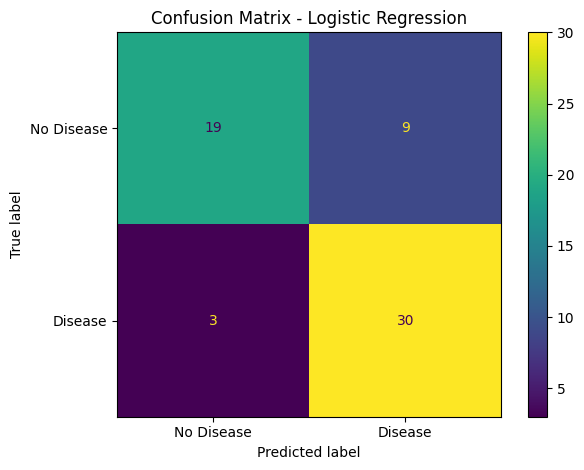

Best parameters : {'C': 1}
CV accuracy     : 0.8349489795918366
Train accuracy  : 0.8512396694214877
Test accuracy   : 0.8032786885245902
Precision       : 0.7692307692307693
Recall          : 0.9090909090909091
Specificity     : 0.6785714285714286
F1-score        : 0.8333333333333334
ROC-AUC         : 0.8658008658008658
Overfit gap     : 0.04796098089689749

Confusion Matrix:
[[19  9]
 [ 3 30]]
TN = 19
FP = 9
FN = 3
TP = 30

Linear SVM


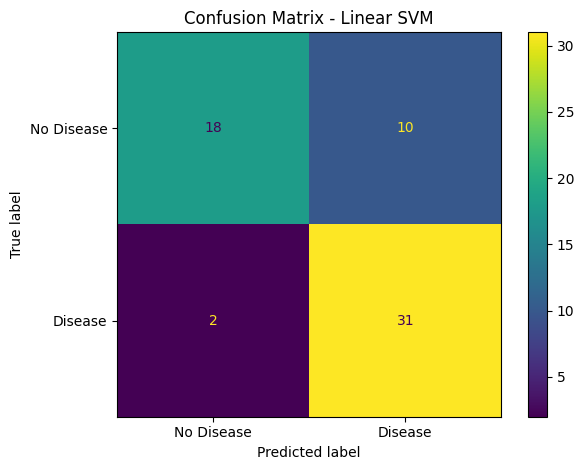

Best parameters : {'C': 1}
CV accuracy     : 0.851530612244898
Train accuracy  : 0.859504132231405
Test accuracy   : 0.8032786885245902
Precision       : 0.7560975609756098
Recall          : 0.9393939393939394
Specificity     : 0.6428571428571429
F1-score        : 0.8378378378378378
ROC-AUC         : 0.8809523809523809
Overfit gap     : 0.056225443706814815

Confusion Matrix:
[[18 10]
 [ 2 31]]
TN = 18
FP = 10
FN = 2
TP = 31

Polynomial SVM


In [ ]:
# 2. GridSearch + Evaluation

results = []

for name, (model, param_grid) in models.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    # Grid Search
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # ------------------------------------------------------
    # Predictions
    # ------------------------------------------------------

    train_pred = best_model.predict(X_train)
    test_pred = best_model.predict(X_test)

    # Probability for ROC-AUC
    test_prob = best_model.predict_proba(X_test)[:, 1]

    # ------------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------------

    cm = confusion_matrix(y_test, test_pred)

    tn, fp, fn, tp = cm.ravel()

    # ------------------------------------------------------
    # Plot Confusion Matrix
    # ------------------------------------------------------

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Disease', 'Disease']
    )

    disp.plot()

    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Metrics
    # ------------------------------------------------------

    accuracy = accuracy_score(y_test, test_pred)

    precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    specificity = tn / (tn + fp)

    f1 = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        test_prob
    )

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    overfit_gap = train_accuracy - accuracy

    # ------------------------------------------------------
    # Store results
    # ------------------------------------------------------

    results.append({
        'Model': name,
        'CV Accuracy': grid.best_score_,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'Overfit Gap': overfit_gap,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Best Parameters': str(grid.best_params_)
    })

    # ------------------------------------------------------
    # Print individual results
    # ------------------------------------------------------

    print("Best parameters :", grid.best_params_)
    print("CV accuracy     :", grid.best_score_)
    print("Train accuracy  :", train_accuracy)
    print("Test accuracy   :", accuracy)
    print("Precision       :", precision)
    print("Recall          :", recall)
    print("Specificity     :", specificity)
    print("F1-score        :", f1)
    print("ROC-AUC         :", roc_auc)
    print("Overfit gap     :", overfit_gap)

    print("\nConfusion Matrix:")
    print(cm)

    print(f"TN = {tn}")
    print(f"FP = {fp}")
    print(f"FN = {fn}")
    print(f"TP = {tp}")


In [ ]:

# 3. Final comparison table


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)



In [ ]:

# 4. Main results table

print("\n\nFINAL MODEL COMPARISON")
print("=" * 150)

main_columns = [
    'Model',
    'CV Accuracy',
    'Train Accuracy',
    'Test Accuracy',
    'Precision',
    'Recall',
    'Specificity',
    'F1',
    'ROC-AUC',
    'Overfit Gap'
]

print(
    results_df[
        main_columns
    ].round(4).to_string(index=False)
)



In [ ]:

# 5. Confusion Matrix values

print("\n\nCONFUSION MATRIX VALUES")
print("=" * 100)

cm_columns = [
    'Model',
    'TN',
    'FP',
    'FN',
    'TP'
]

print(
    results_df[
        cm_columns
    ].to_string(index=False)
)



In [ ]:

# 6. Best Parameters

print("\n\nBEST PARAMETERS")
print("=" * 100)

for _, row in results_df.iterrows():
    print(f"{row['Model']}: {row['Best Parameters']}")